# 06 · Practical Deep Learning — Code

Part A (NumPy): visualize underfitting/good-fit/overfitting directly, run a small hyperparameter grid search, then compute a confusion matrix, precision/recall/F1, and ROC-AUC by hand.
Part B (PyTorch + scikit-learn): the same evaluation metrics computed the standard, practical way.

# Part A — NumPy From Scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.random.seed(42)

X, y = make_moons(n_samples=400, noise=0.25, random_state=42)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
y_train_c = y_train.reshape(-1,1); y_val_c = y_val.reshape(-1,1); y_test_c = y_test.reshape(-1,1)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print("Remember: the test set is touched ONCE, at the very end, to report a final honest number.")

def sigmoid(z): return 1/(1+np.exp(-np.clip(z,-500,500)))
def relu(z): return np.maximum(0,z)
def relu_derivative(z): return (z>0).astype(float)
def bce(y_true,y_pred,eps=1e-9):
    y_pred = np.clip(y_pred, eps, 1-eps)
    return -np.mean(y_true*np.log(y_pred)+(1-y_true)*np.log(1-y_pred))

class Net:
    def __init__(self, hidden_dim, lr=0.3):
        self.W1 = np.random.randn(2, hidden_dim)*np.sqrt(2.0/2)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, 1)*np.sqrt(2.0/hidden_dim)
        self.b2 = np.zeros((1,1))
        self.lr = lr
    def forward(self, X):
        self.z1 = X@self.W1+self.b1; self.a1 = relu(self.z1)
        self.z2 = self.a1@self.W2+self.b2; self.a2 = sigmoid(self.z2)
        return self.a2
    def backward(self, X, y):
        n = X.shape[0]
        dz2 = (self.a2-y)/n
        dW2 = self.a1.T@dz2; db2 = dz2.sum(0,keepdims=True)
        da1 = dz2@self.W2.T; dz1 = da1*relu_derivative(self.z1)
        dW1 = X.T@dz1; db1 = dz1.sum(0,keepdims=True)
        self.W2 -= self.lr*dW2; self.b2 -= self.lr*db2
        self.W1 -= self.lr*dW1; self.b1 -= self.lr*db1
    def train(self, X, y, X_val, y_val, epochs=500):
        tr, va = [], []
        for _ in range(epochs):
            pred = self.forward(X); self.backward(X,y)
            tr.append(bce(y,pred)); va.append(bce(y_val, self.forward(X_val)))
        return tr, va

Train: 240  Val: 80  Test: 80
Remember: the test set is touched ONCE, at the very end, to report a final honest number.


## 1-3. Underfitting vs Good Fit vs Overfitting (bias/variance in action)

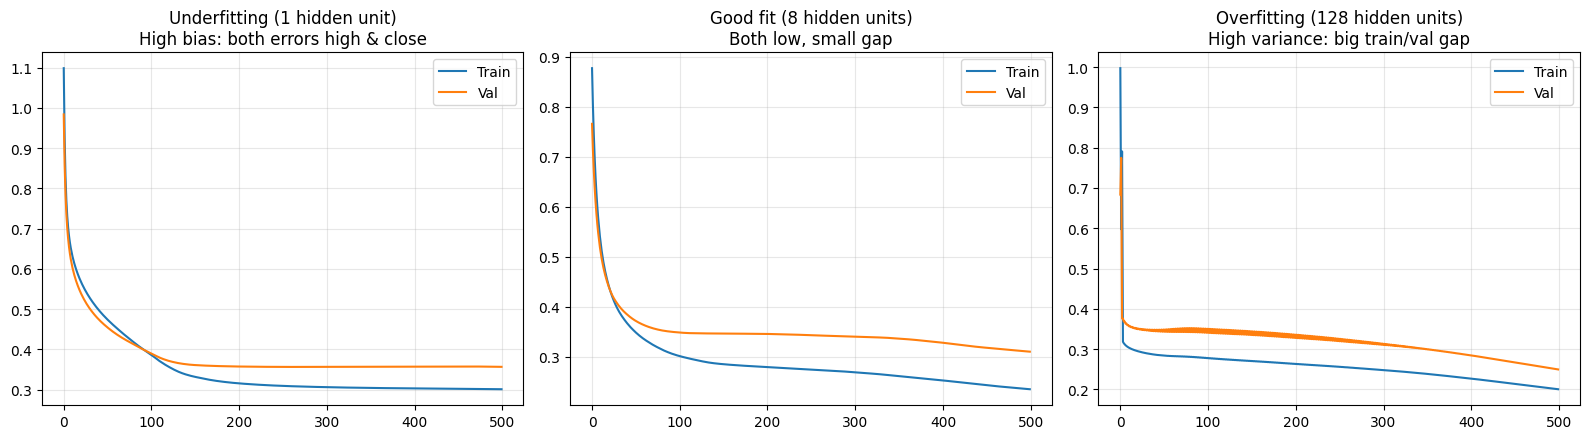

In [2]:
np.random.seed(1); net_under = Net(hidden_dim=1, lr=0.3)   # too little capacity -> HIGH BIAS
tr_u, va_u = net_under.train(X_train, y_train_c, X_val, y_val_c, epochs=500)

np.random.seed(1); net_good = Net(hidden_dim=8, lr=0.3)    # about right
tr_g, va_g = net_good.train(X_train, y_train_c, X_val, y_val_c, epochs=500)

np.random.seed(1); net_over = Net(hidden_dim=128, lr=0.3)  # way too much capacity -> HIGH VARIANCE
tr_o, va_o = net_over.train(X_train, y_train_c, X_val, y_val_c, epochs=500)

fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
for ax, (tr, va, title) in zip(axes, [
        (tr_u, va_u, "Underfitting (1 hidden unit)\nHigh bias: both errors high & close"),
        (tr_g, va_g, "Good fit (8 hidden units)\nBoth low, small gap"),
        (tr_o, va_o, "Overfitting (128 hidden units)\nHigh variance: big train/val gap")]):
    ax.plot(tr, label='Train'); ax.plot(va, label='Val')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning (grid search over learning rate x hidden size)

In [3]:
learning_rates = [0.01, 0.1, 0.5]
hidden_sizes = [4, 16, 64]

results = []
for lr in learning_rates:
    for hd in hidden_sizes:
        np.random.seed(1)
        net = Net(hidden_dim=hd, lr=lr)
        tr, va = net.train(X_train, y_train_c, X_val, y_val_c, epochs=300)
        results.append({'lr': lr, 'hidden_dim': hd, 'final_val_loss': va[-1]})

import pandas as pd
results_df = pd.DataFrame(results).sort_values('final_val_loss')
print("Grid search results (best first) -- selected using VALIDATION loss, never test loss:")
print(results_df.to_string(index=False))

best = results_df.iloc[0]
print(f"\nBest hyperparameters: lr={best['lr']}, hidden_dim={int(best['hidden_dim'])}")

Grid search results (best first) -- selected using VALIDATION loss, never test loss:
  lr  hidden_dim  final_val_loss
0.50          64        0.254301
0.50          16        0.274637
0.50           4        0.291397
0.10           4        0.335877
0.10          16        0.342836
0.10          64        0.342915
0.01          64        0.346610
0.01          16        0.458567
0.01           4        0.637728

Best hyperparameters: lr=0.5, hidden_dim=64


## 6-7. Confusion Matrix, Precision, Recall, F1 (computed by hand)

Confusion Matrix:
  TP=33  FN=4
  FP=4  TN=39

Accuracy:  0.900
Precision: 0.892  (of predicted positives, how many were right)
Recall:    0.892  (of actual positives, how many did we find)
F1:        0.892


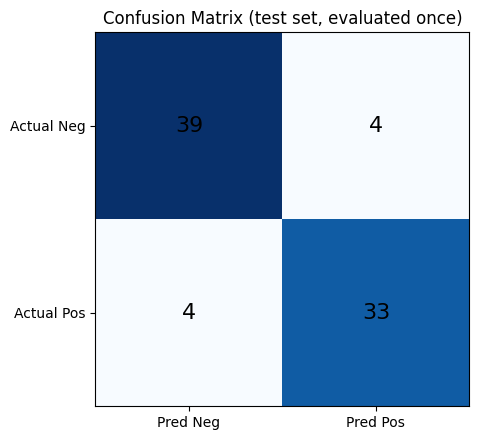

In [4]:
# Train final model with the best hyperparameters found above, evaluate ONCE on the test set
np.random.seed(1)
final_net = Net(hidden_dim=int(best['hidden_dim']), lr=best['lr'])
final_net.train(X_train, y_train_c, X_val, y_val_c, epochs=500)

test_probs = final_net.forward(X_test).ravel()
test_preds = (test_probs > 0.5).astype(int)

def confusion_matrix_manual(y_true, y_pred):
    TP = np.sum((y_true==1)&(y_pred==1))
    TN = np.sum((y_true==0)&(y_pred==0))
    FP = np.sum((y_true==0)&(y_pred==1))
    FN = np.sum((y_true==1)&(y_pred==0))
    return TP, TN, FP, FN

TP, TN, FP, FN = confusion_matrix_manual(y_test, test_preds)
print(f"Confusion Matrix:\n  TP={TP}  FN={FN}\n  FP={FP}  TN={TN}")

precision = TP / (TP + FP) if (TP+FP) > 0 else 0
recall = TP / (TP + FN) if (TP+FN) > 0 else 0
f1 = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0
accuracy = (TP+TN) / (TP+TN+FP+FN)

print(f"\nAccuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}  (of predicted positives, how many were right)")
print(f"Recall:    {recall:.3f}  (of actual positives, how many did we find)")
print(f"F1:        {f1:.3f}")

fig, ax = plt.subplots(figsize=(5,4.5))
cm = np.array([[TN, FP],[FN, TP]])
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=16)
ax.set_xticks([0,1]); ax.set_xticklabels(['Pred Neg','Pred Pos'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Actual Neg','Actual Pos'])
ax.set_title("Confusion Matrix (test set, evaluated once)")
plt.tight_layout()
plt.show()

## 8. ROC-AUC (computed by hand, sweeping the threshold)

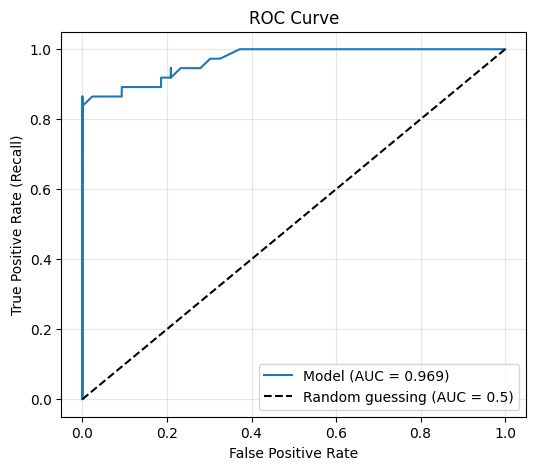

AUC = 0.969 -- summarizes ranking quality across EVERY possible threshold, not just 0.5


In [5]:
def roc_curve_manual(y_true, y_scores, thresholds):
    tpr_list, fpr_list = [], []
    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        TP, TN, FP, FN = confusion_matrix_manual(y_true, y_pred)
        tpr = TP/(TP+FN) if (TP+FN)>0 else 0     # = Recall
        fpr = FP/(FP+TN) if (FP+TN)>0 else 0
        tpr_list.append(tpr); fpr_list.append(fpr)
    return np.array(fpr_list), np.array(tpr_list)

thresholds = np.linspace(0, 1, 100)
fpr, tpr = roc_curve_manual(y_test, test_probs, thresholds)

# AUC via the trapezoidal rule -- fpr must be sorted ascending
order = np.argsort(fpr)
trapz_fn = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz  # NumPy >=2.0 renamed trapz -> trapezoid
auc = trapz_fn(tpr[order], fpr[order])

plt.figure(figsize=(6,5))
plt.plot(fpr[order], tpr[order], label=f'Model (AUC = {auc:.3f})')
plt.plot([0,1],[0,1], 'k--', label='Random guessing (AUC = 0.5)')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f"AUC = {auc:.3f} -- summarizes ranking quality across EVERY possible threshold, not just 0.5")

---
# Part B — PyTorch + scikit-learn Equivalent

scikit-learn confusion matrix:
 [[38  5]
 [ 5 32]]

Precision: 0.865  Recall: 0.865  F1: 0.865  AUC: 0.971


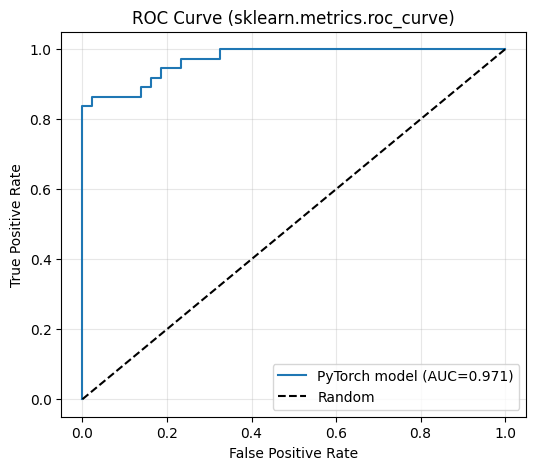

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

torch.manual_seed(1)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train_c, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

class TorchNet(nn.Module):
    def __init__(self, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

model = TorchNet(hidden_dim=int(best['hidden_dim']))
optimizer = optim.SGD(model.parameters(), lr=best['lr'])
criterion = nn.BCELoss()

for epoch in range(500):
    optimizer.zero_grad()
    loss = criterion(model(X_train_t), y_train_t)
    loss.backward(); optimizer.step()

with torch.no_grad():
    test_probs_t = model(X_test_t).numpy().ravel()
test_preds_t = (test_probs_t > 0.5).astype(int)

# --- scikit-learn's standard metric implementations ---
cm_sklearn = confusion_matrix(y_test, test_preds_t)
precision_sk = precision_score(y_test, test_preds_t)
recall_sk = recall_score(y_test, test_preds_t)
f1_sk = f1_score(y_test, test_preds_t)
fpr_sk, tpr_sk, _ = roc_curve(y_test, test_probs_t)
auc_sk = auc(fpr_sk, tpr_sk)

print("scikit-learn confusion matrix:\n", cm_sklearn)
print(f"\nPrecision: {precision_sk:.3f}  Recall: {recall_sk:.3f}  F1: {f1_sk:.3f}  AUC: {auc_sk:.3f}")

plt.figure(figsize=(6,5))
plt.plot(fpr_sk, tpr_sk, label=f'PyTorch model (AUC={auc_sk:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve (sklearn.metrics.roc_curve)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()